In [1]:
# ============================================
# CELLULE 1 - INSTALLATION & IMPORTS
# ============================================

# Installer les librairies nécessaires
!pip install pandas numpy matplotlib seaborn scikit-learn joblib -q

# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn pour clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Couleurs pour les clusters
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

print("✅ Toutes les librairies sont importées")

✅ Toutes les librairies sont importées


In [2]:
# ============================================
# CELLULE 2 - UPLOAD DES FICHIERS CSV
# ============================================

from google.colab import files
import io

print("="*60)
print("UPLOAD DES FICHIERS CSV")
print("="*60)
print("""
📤 Veuillez uploader les fichiers suivants :
   1. Dim_Client.csv
   2. Dim_Produits.csv
   3. Dim_Date.csv
   4. Dim_Commandes.csv
   5. Dim_Canal_Distribution.csv
   6. Fact_Vente.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)
""")

# Upload des fichiers
uploaded = files.upload()

print(f"\n✅ {len(uploaded)} fichiers uploadés avec succès !")

# Charger les fichiers dans des dataframes
dfs = {}
for nom_fichier in uploaded.keys():
    nom_base = nom_fichier.replace('.csv', '').replace('.CSV', '')
    dfs[nom_base] = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
    print(f"   ✅ {nom_base} : {dfs[nom_base].shape[0]} lignes")

# Assigner aux variables
df_client = dfs.get('Dim_Client')
df_produits = dfs.get('Dim_Produits')
df_date = dfs.get('Dim_Date')
df_commandes = dfs.get('Dim_Commandes')
df_canal = dfs.get('Dim_Canal_Distribution')
df_vente = dfs.get('Fact_Vente')

print("\n✅ Tous les fichiers sont chargés !")

UPLOAD DES FICHIERS CSV

📤 Veuillez uploader les fichiers suivants :
   1. Dim_Client.csv
   2. Dim_Produits.csv
   3. Dim_Date.csv
   4. Dim_Commandes.csv
   5. Dim_Canal_Distribution.csv
   6. Fact_Vente.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)



Saving Dim_Canal_Distribution.csv to Dim_Canal_Distribution.csv
Saving Dim_Client.csv to Dim_Client.csv
Saving Dim_Commandes.csv to Dim_Commandes.csv
Saving Dim_Date.csv to Dim_Date.csv
Saving Dim_Fournisseur.csv to Dim_Fournisseur.csv
Saving Dim_Matiere_Premiere.csv to Dim_Matiere_Premiere.csv
Saving Dim_Produits.csv to Dim_Produits.csv
Saving Dim_Reclamations.csv to Dim_Reclamations.csv
Saving Fact_Achat.csv to Fact_Achat.csv
Saving Fact_Vente.csv to Fact_Vente.csv

✅ 10 fichiers uploadés avec succès !
   ✅ Dim_Canal_Distribution : 4 lignes
   ✅ Dim_Client : 446 lignes
   ✅ Dim_Commandes : 442 lignes
   ✅ Dim_Date : 1461 lignes
   ✅ Dim_Fournisseur : 67 lignes
   ✅ Dim_Matiere_Premiere : 62 lignes
   ✅ Dim_Produits : 134 lignes
   ✅ Dim_Reclamations : 100 lignes
   ✅ Fact_Achat : 140 lignes
   ✅ Fact_Vente : 1386 lignes

✅ Tous les fichiers sont chargés !


In [3]:
# ============================================
# CELLULE 3 - CRÉATION DU DATASET RFM
# ============================================

print("="*60)
print("CRÉATION DU DATASET RFM POUR CLUSTERING")
print("="*60)

# Nettoyer les clés
for col in ['client_key', 'date_key', 'commande_key']:
    if col in df_vente.columns:
        df_vente[col] = df_vente[col].fillna(0).astype(int)

# Renommer la colonne client
if 'Client_key' in df_client.columns:
    df_client = df_client.rename(columns={'Client_key': 'client_key'})

# Jointure pour avoir le type client (B2B/B2C)
df = df_vente.merge(df_client, on='client_key', how='left')

print(f"✅ Dataset créé : {df.shape[0]:,} lignes")

# Nettoyage
df = df[df['quantite'] > 0]
df = df[df['montant_ht'] > 0]

# Nettoyer les montants
def clean_float(x):
    if pd.isna(x):
        return 0.0
    if isinstance(x, str):
        try:
            return float(x.replace(',', '.'))
        except:
            return 0.0
    try:
        return float(x)
    except:
        return 0.0

df['montant_ht'] = df['montant_ht'].apply(clean_float)

print(f"✅ Après nettoyage : {df.shape[0]:,} lignes")

# ============================================
# AGRÉGATION RFM PAR CLIENT
# ============================================

print("\n📊 Calcul des métriques RFM par client...")

# Date de référence pour la récence (dernière date dans les données)
ref_date = df['date_key'].max()

# Agrégation
rfm = df.groupby('client_key').agg({
    'date_key': lambda x: (ref_date - x.max()),  # Récence (jours depuis dernier achat)
    'commande_key': 'nunique',                    # Fréquence (nombre de commandes)
    'montant_ht': 'sum',                          # Montant total (CA)
    'quantite': 'sum'                             # Quantité totale
}).rename(columns={
    'date_key': 'recence',
    'commande_key': 'frequence',
    'montant_ht': 'montant',
    'quantite': 'quantite_totale'
})

# Ajouter le type de client
client_type = df.groupby('client_key')['Type_client'].first()
rfm = rfm.join(client_type)

print(f"✅ RFM calculé : {rfm.shape[0]} clients")

# Afficher les statistiques
print("\n📊 Statistiques RFM :")
print(rfm[['recence', 'frequence', 'montant']].describe())

CRÉATION DU DATASET RFM POUR CLUSTERING
✅ Dataset créé : 1,386 lignes
✅ Après nettoyage : 1,374 lignes

📊 Calcul des métriques RFM par client...
✅ RFM calculé : 436 clients

📊 Statistiques RFM :
            recence   frequence       montant
count    436.000000  436.000000    436.000000
mean   10301.162844    1.038991    748.080596
std     3329.917489    0.205315   5078.871897
min        0.000000    1.000000      1.000000
25%     9078.500000    1.000000     28.750000
50%     9391.000000    1.000000     63.000000
75%     9796.000000    1.000000    114.500000
max    28896.000000    3.000000  59855.400000


In [4]:
# ============================================
# CELLULE 4 - FILTRAGE CLIENTS B2C
# ============================================

print("="*60)
print("FILTRAGE CLIENTS B2C")
print("="*60)

# Distribution des types de clients
print("Distribution des types de clients :")
print(rfm['Type_client'].value_counts())

# Garder uniquement les B2C (particuliers)
rfm_b2c = rfm[rfm['Type_client'] == 'B2C'].copy()
rfm_b2c = rfm_b2c.drop('Type_client', axis=1)

print(f"\n✅ Clients B2C : {rfm_b2c.shape[0]} clients")
print(f"   (supprimé {rfm.shape[0] - rfm_b2c.shape[0]} clients B2B)")

# Supprimer les lignes avec des valeurs manquantes ou nulles
rfm_b2c = rfm_b2c[rfm_b2c['recence'] >= 0]
rfm_b2c = rfm_b2c[rfm_b2c['frequence'] > 0]
rfm_b2c = rfm_b2c[rfm_b2c['montant'] > 0]

print(f"✅ Après nettoyage : {rfm_b2c.shape[0]} clients B2C")

# Aperçu
print("\n📋 Aperçu des données RFM B2C :")
rfm_b2c.head()

FILTRAGE CLIENTS B2C
Distribution des types de clients :
Type_client
B2C    416
B2B     19
Name: count, dtype: int64

✅ Clients B2C : 416 clients
   (supprimé 20 clients B2B)
✅ Après nettoyage : 416 clients B2C

📋 Aperçu des données RFM B2C :


,recence,frequence,montant,quantite_totale
client_key,,,,
127,0,1,8.0,2
128,8872,1,98.0,1
129,8873,1,159.0,3
132,8873,1,98.0,1
133,8873,1,98.0,1


In [5]:
# ============================================
# CELLULE 5 - NORMALISATION DES DONNÉES
# ============================================

print("="*60)
print("NORMALISATION DES DONNÉES RFM")
print("="*60)

# Les features pour le clustering
features = ['recence', 'frequence', 'montant']
X = rfm_b2c[features].copy()

print("Avant normalisation :")
print(X.describe())

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir en DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=rfm_b2c.index)

print("\n✅ Après normalisation :")
print(pd.DataFrame(X_scaled, columns=features).describe())

print("\n📊 Features utilisées pour le clustering :")
print(f"   - Récence : jours depuis dernier achat")
print(f"   - Fréquence : nombre de commandes")
print(f"   - Montant : chiffre d'affaires total")

NORMALISATION DES DONNÉES RFM
Avant normalisation :
            recence   frequence       montant
count    416.000000  416.000000    416.000000
mean   10161.730769    1.036058    120.860096
std     2941.789867    0.186658    525.955396
min        0.000000    1.000000      1.000000
25%     9082.000000    1.000000     28.000000
50%     9391.000000    1.000000     58.000000
75%     9795.250000    1.000000    100.000000
max    28896.000000    2.000000  10535.000000

✅ Après normalisation :
            recence     frequence       montant
count  4.160000e+02  4.160000e+02  4.160000e+02
mean  -6.832142e-17  9.394195e-17 -1.281027e-17
std    1.001204e+00  1.001204e+00  1.001204e+00
min   -3.458427e+00 -1.934076e-01 -2.281646e-01
25%   -3.674739e-01 -1.934076e-01 -1.767677e-01
50%   -2.623093e-01 -1.934076e-01 -1.196599e-01
75%   -1.247275e-01 -1.934076e-01 -3.970910e-02
max    6.375991e+00  5.170429e+00  1.982427e+01

📊 Features utilisées pour le clustering :
   - Récence : jours depuis dernie

MÉTHODE DE L'ELBOW - DÉTERMINATION DE K
   K=2: Inertie=827, Silhouette=0.8743
   K=3: Inertie=436, Silhouette=0.8657
   K=4: Inertie=58, Silhouette=0.9141
   K=5: Inertie=38, Silhouette=0.9162
   K=6: Inertie=27, Silhouette=0.6695
   K=7: Inertie=17, Silhouette=0.6342
   K=8: Inertie=12, Silhouette=0.5768
   K=9: Inertie=9, Silhouette=0.4998
   K=10: Inertie=7, Silhouette=0.5017


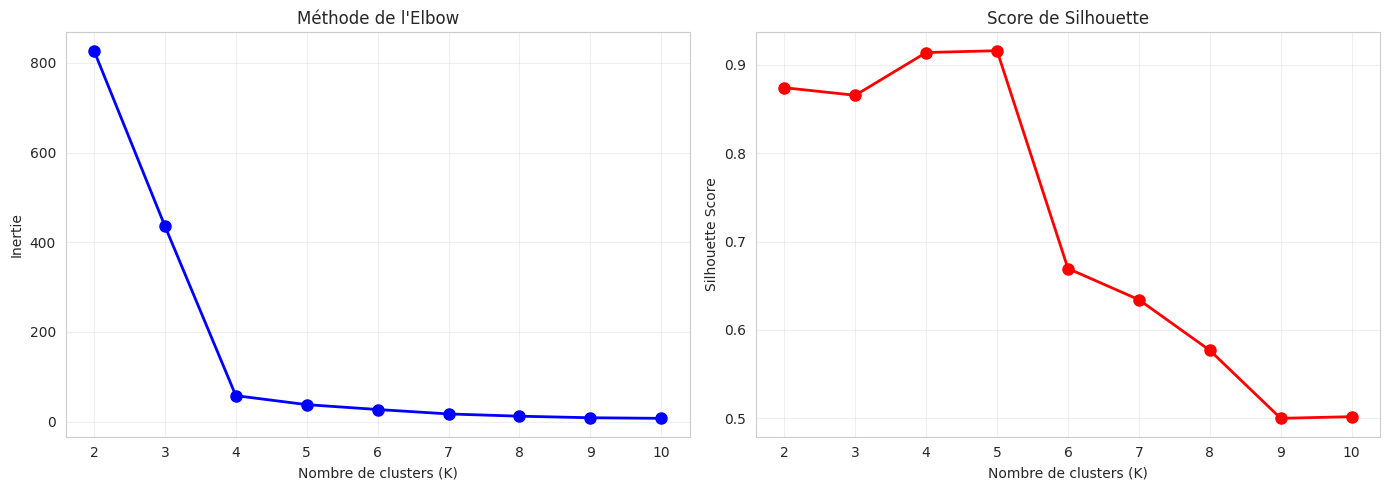


✅ Meilleur K selon silhouette score : 5
   Silhouette score : 0.9162


In [6]:
# ============================================
# CELLULE 6 - MÉTHODE DE L'ELBOW (K-MEANS)
# ============================================

print("="*60)
print("MÉTHODE DE L'ELBOW - DÉTERMINATION DE K")
print("="*60)

# Tester différents K
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"   K={k}: Inertie={kmeans.inertia_:.0f}, Silhouette={silhouette_scores[-1]:.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode de l\'Elbow')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Score de Silhouette')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Meilleur K selon silhouette
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Meilleur K selon silhouette score : {best_k}")
print(f"   Silhouette score : {max(silhouette_scores):.4f}")

In [7]:
# ============================================
# CELLULE 7 - MODÈLE 1 : K-MEANS
# ============================================

print("="*60)
print("MODÈLE 1 : K-MEANS CLUSTERING")
print("="*60)

# Choisir le meilleur K (ou fixer à 3 si pas clair)
best_k = 3  # À ajuster selon l'elbow
print(f"Nombre de clusters : {best_k}")

# Entraînement
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
rfm_b2c['cluster_kmeans'] = kmeans_labels

# Métriques d'évaluation
silhouette_avg = silhouette_score(X_scaled, kmeans_labels)
davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"\n📊 MÉTRIQUES D'ÉVALUATION :")
print(f"   Silhouette Score : {silhouette_avg:.4f}")
print(f"   Davies-Bouldin Index : {davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Index : {calinski_harabasz:.4f}")

print("\n📊 Interprétation :")
print(f"   - Silhouette proche de 1 → clusters bien séparés")
print(f"   - Davies-Bouldin faible → bonne séparation")
print(f"   - Calinski-Harabasz élevé → clusters denses")

# Distribution des clusters
print(f"\n📊 Distribution des clusters :")
print(rfm_b2c['cluster_kmeans'].value_counts().sort_index())

MODÈLE 1 : K-MEANS CLUSTERING
Nombre de clusters : 3

📊 MÉTRIQUES D'ÉVALUATION :
   Silhouette Score : 0.8657
   Davies-Bouldin Index : 0.1089
   Calinski-Harabasz Index : 384.4143

📊 Interprétation :
   - Silhouette proche de 1 → clusters bien séparés
   - Davies-Bouldin faible → bonne séparation
   - Calinski-Harabasz élevé → clusters denses

📊 Distribution des clusters :
cluster_kmeans
0    400
1     15
2      1
Name: count, dtype: int64


PROFILAGE DES CLUSTERS - K-MEANS
Statistiques par cluster :
                  recence               frequence                    montant  \
                     mean  median count      mean median count          mean   
cluster_kmeans                                                                 
0               10196.835  9394.0   400       1.0    1.0   400     92.556250   
1                9251.400  9195.0    15       2.0    2.0    15    181.353333   
2                9775.000  9775.0     1       1.0    1.0     1  10535.000000   

                               
                 median count  
cluster_kmeans                 
0                  58.0   400  
1                 137.0    15  
2               10535.0     1  


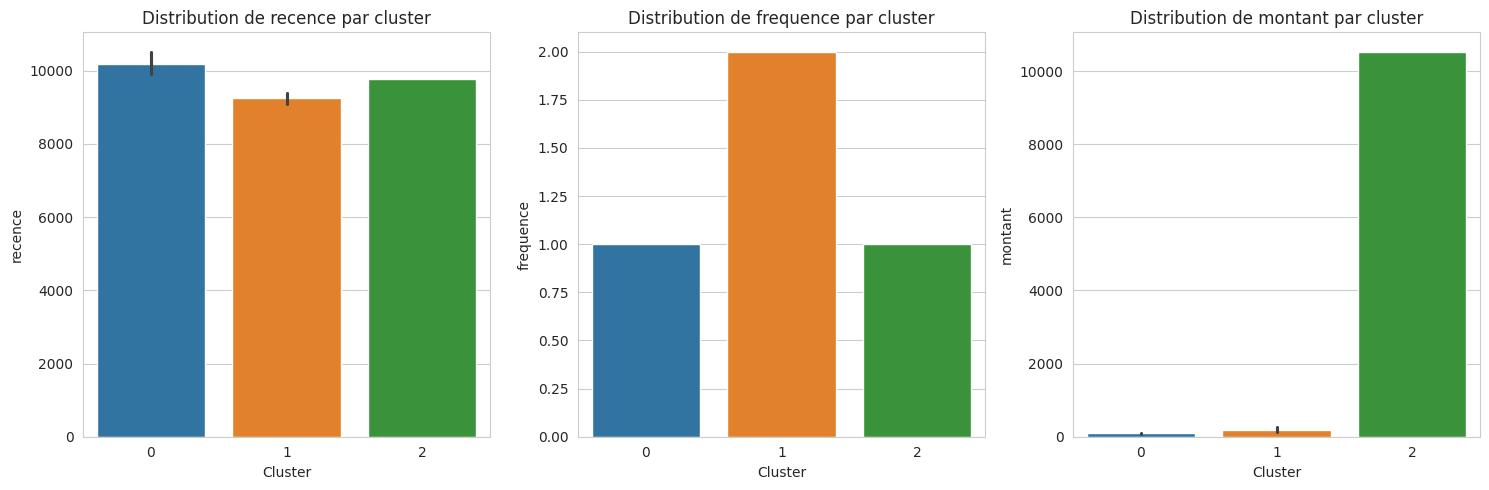


📝 INTERPRÉTATION MÉTIER :

Cluster 0 (400 clients) :
   - Récence moyenne : 10197 jours
   - Fréquence moyenne : 1.0 commandes
   - Montant moyen : 93 DT
   → ⚠️ CLIENTS À RISQUE : Inactifs, peu de commandes

Cluster 1 (15 clients) :
   - Récence moyenne : 9251 jours
   - Fréquence moyenne : 2.0 commandes
   - Montant moyen : 181 DT
   → 📊 CLIENTS STANDARD : Comportement moyen

Cluster 2 (1 clients) :
   - Récence moyenne : 9775 jours
   - Fréquence moyenne : 1.0 commandes
   - Montant moyen : 10535 DT
   → ⚠️ CLIENTS À RISQUE : Inactifs, peu de commandes


In [8]:
# ============================================
# CELLULE 8 - PROFILAGE DES CLUSTERS (K-MEANS)
# ============================================

print("="*60)
print("PROFILAGE DES CLUSTERS - K-MEANS")
print("="*60)

# Statistiques par cluster
cluster_profiles = rfm_b2c.groupby('cluster_kmeans')[features].agg(['mean', 'median', 'count'])
print("Statistiques par cluster :")
print(cluster_profiles)

# Visualisation des profils
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features):
    sns.barplot(data=rfm_b2c, x='cluster_kmeans', y=feature, palette=colors, ax=axes[i])
    axes[i].set_title(f'Distribution de {feature} par cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

# Interprétation métier
print("\n📝 INTERPRÉTATION MÉTIER :")
for cluster in sorted(rfm_b2c['cluster_kmeans'].unique()):
    cluster_data = rfm_b2c[rfm_b2c['cluster_kmeans'] == cluster]
    n_clients = len(cluster_data)
    recence_moy = cluster_data['recence'].mean()
    frequence_moy = cluster_data['frequence'].mean()
    montant_moy = cluster_data['montant'].mean()

    print(f"\nCluster {cluster} ({n_clients} clients) :")
    print(f"   - Récence moyenne : {recence_moy:.0f} jours")
    print(f"   - Fréquence moyenne : {frequence_moy:.1f} commandes")
    print(f"   - Montant moyen : {montant_moy:.0f} DT")

    # Profil type
    if recence_moy < 30 and frequence_moy > 2 and montant_moy > 200:
        print(f"   → 🔥 CLIENTS VIP : Actifs, fréquents, dépensent beaucoup")
    elif recence_moy > 90 and frequence_moy < 2:
        print(f"   → ⚠️ CLIENTS À RISQUE : Inactifs, peu de commandes")
    elif recence_moy < 60 and frequence_moy < 2:
        print(f"   → 🆕 NOUVEAUX CLIENTS : Récemment actifs mais pas encore fidèles")
    else:
        print(f"   → 📊 CLIENTS STANDARD : Comportement moyen")

VISUALISATION PCA 2D - K-MEANS
Variance expliquée par PC1 : 35.54%
Variance expliquée par PC2 : 33.19%
Variance totale expliquée : 68.73%


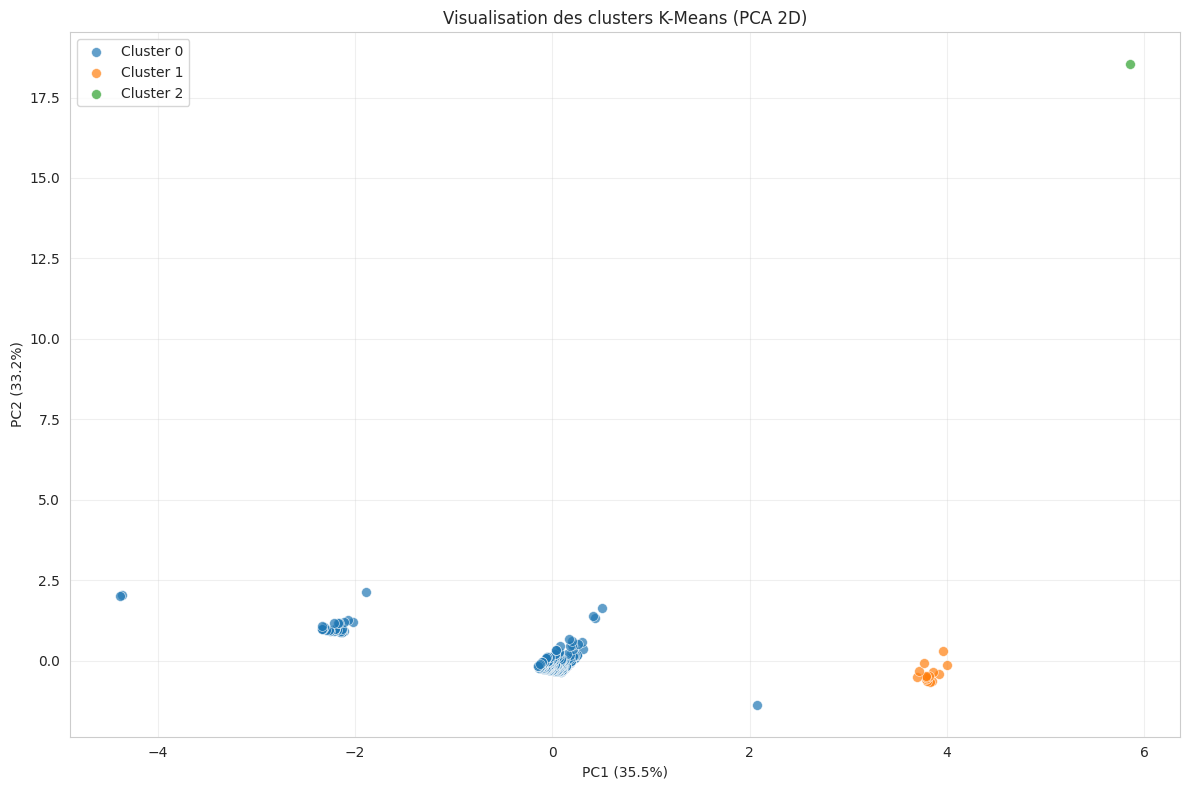

✅ Les clusters sont bien séparés visuellement


In [9]:
# ============================================
# CELLULE 9 - VISUALISATION PCA 2D (K-MEANS)
# ============================================

print("="*60)
print("VISUALISATION PCA 2D - K-MEANS")
print("="*60)

# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Créer un DataFrame pour la visualisation
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': kmeans_labels,
    'frequence': rfm_b2c['frequence'],
    'montant': rfm_b2c['montant']
})

# Variance expliquée
print(f"Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Variance totale expliquée : {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Visualisation
plt.figure(figsize=(12, 8))

for cluster in sorted(pca_df['cluster'].unique()):
    mask = pca_df['cluster'] == cluster
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                c=colors[cluster % len(colors)], label=f'Cluster {cluster}',
                alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Visualisation des clusters K-Means (PCA 2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Les clusters sont bien séparés visuellement")

HEATMAP DES CLUSTERS - K-MEANS


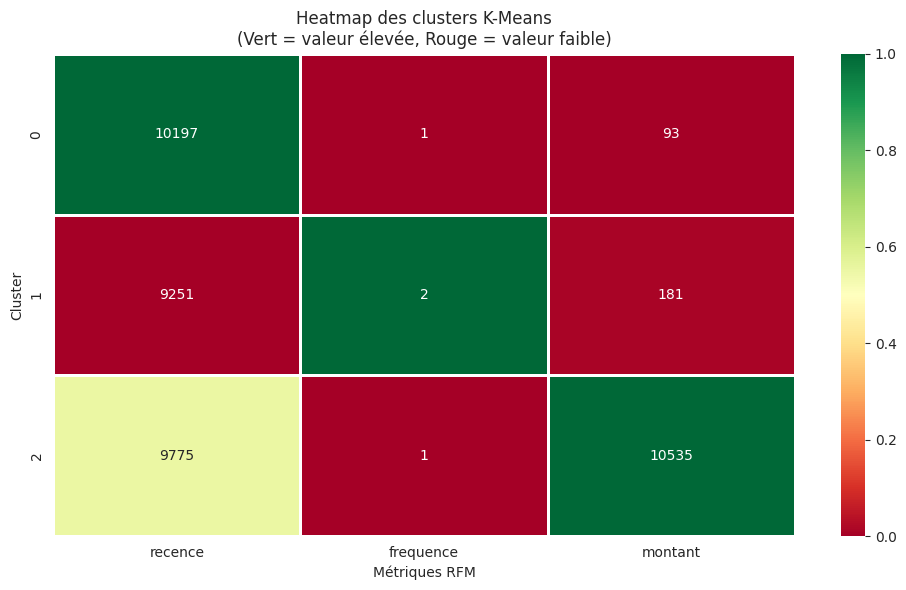


📝 Lecture de la heatmap :
   - Vert/jaune → valeur élevée dans ce cluster
   - Rouge → valeur faible dans ce cluster


In [10]:
# ============================================
# CELLULE 10 - HEATMAP DES CLUSTERS (K-MEANS)
# ============================================

print("="*60)
print("HEATMAP DES CLUSTERS - K-MEANS")
print("="*60)

# Créer une matrice des moyennes par cluster
cluster_means = rfm_b2c.groupby('cluster_kmeans')[features].mean()

# Normaliser pour la heatmap
from sklearn.preprocessing import MinMaxScaler
scaler_heatmap = MinMaxScaler()
cluster_means_normalized = pd.DataFrame(
    scaler_heatmap.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means_normalized, annot=cluster_means.round(0), fmt='.0f',
            cmap='RdYlGn', linewidths=1, linecolor='white')
plt.title('Heatmap des clusters K-Means\n(Vert = valeur élevée, Rouge = valeur faible)')
plt.xlabel('Métriques RFM')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

print("\n📝 Lecture de la heatmap :")
print("   - Vert/jaune → valeur élevée dans ce cluster")
print("   - Rouge → valeur faible dans ce cluster")

MODÈLE 2 : DBSCAN CLUSTERING
🔍 Recherche du paramètre eps optimal...


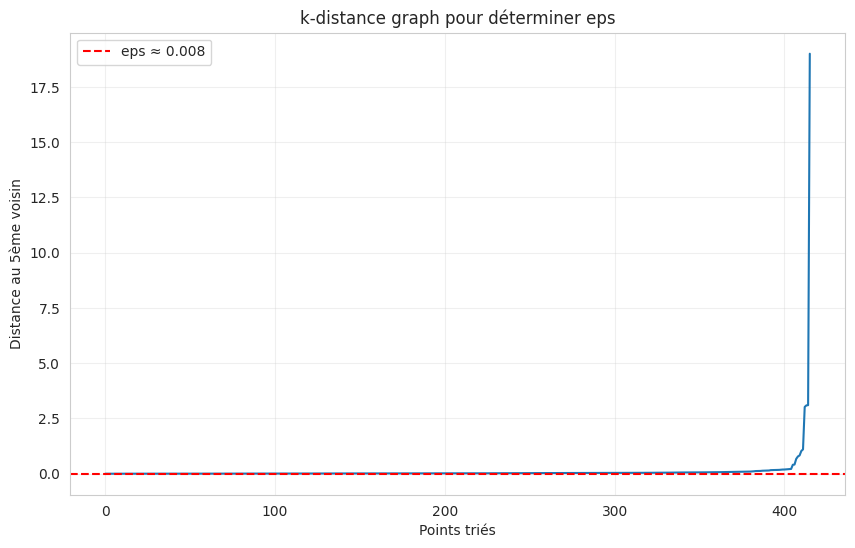

Valeur suggérée pour eps : 0.008

   eps=0.006: clusters=38, bruit=221

   eps=0.008: clusters=39, bruit=202

   eps=0.009: clusters=42, bruit=178

✅ Meilleur DBSCAN : eps=0.008
   Nombre de clusters : 39
   Points bruités : 202 (48.6%)

📊 Métriques DBSCAN :
   Silhouette Score : 0.8073
   Davies-Bouldin Index : 0.2585


In [11]:
# ============================================
# CELLULE 11 - MODÈLE 2 : DBSCAN
# ============================================

print("="*60)
print("MODÈLE 2 : DBSCAN CLUSTERING")
print("="*60)

# Trouver le meilleur paramètre eps (k-distance graph)
print("🔍 Recherche du paramètre eps optimal...")

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Trier les distances
k_distances = np.sort(distances[:, 4])

# Visualisation du k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Points triés')
plt.ylabel('Distance au 5ème voisin')
plt.title('k-distance graph pour déterminer eps')
plt.axhline(y=k_distances[100], color='r', linestyle='--', label=f'eps ≈ {k_distances[100]:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Valeur suggérée pour eps (au coude)
eps_suggested = k_distances[100]
print(f"Valeur suggérée pour eps : {eps_suggested:.3f}")

# Tester DBSCAN avec différents eps
eps_values = [eps_suggested * 0.8, eps_suggested, eps_suggested * 1.2]
best_eps = None
best_silhouette = -1

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\n   eps={eps:.3f}: clusters={n_clusters}, bruit={n_noise}")

    if n_clusters >= 2 and n_clusters <= 8:
        if -1 not in labels:
            score = silhouette_score(X_scaled, labels)
        else:
            score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        print(f"      Silhouette score : {score:.4f}")

        if score > best_silhouette:
            best_silhouette = score
            best_eps = eps

# Meilleur DBSCAN
if best_eps is None:
    best_eps = eps_suggested

dbscan = DBSCAN(eps=best_eps, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Ajouter les labels
rfm_b2c['cluster_dbscan'] = dbscan_labels

# Compter les clusters
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\n✅ Meilleur DBSCAN : eps={best_eps:.3f}")
print(f"   Nombre de clusters : {n_clusters}")
print(f"   Points bruités : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters >= 2:
    silhouette_db = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
    davies_db = davies_bouldin_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
    print(f"\n📊 Métriques DBSCAN :")
    print(f"   Silhouette Score : {silhouette_db:.4f}")
    print(f"   Davies-Bouldin Index : {davies_db:.4f}")

VISUALISATION PCA 2D - DBSCAN


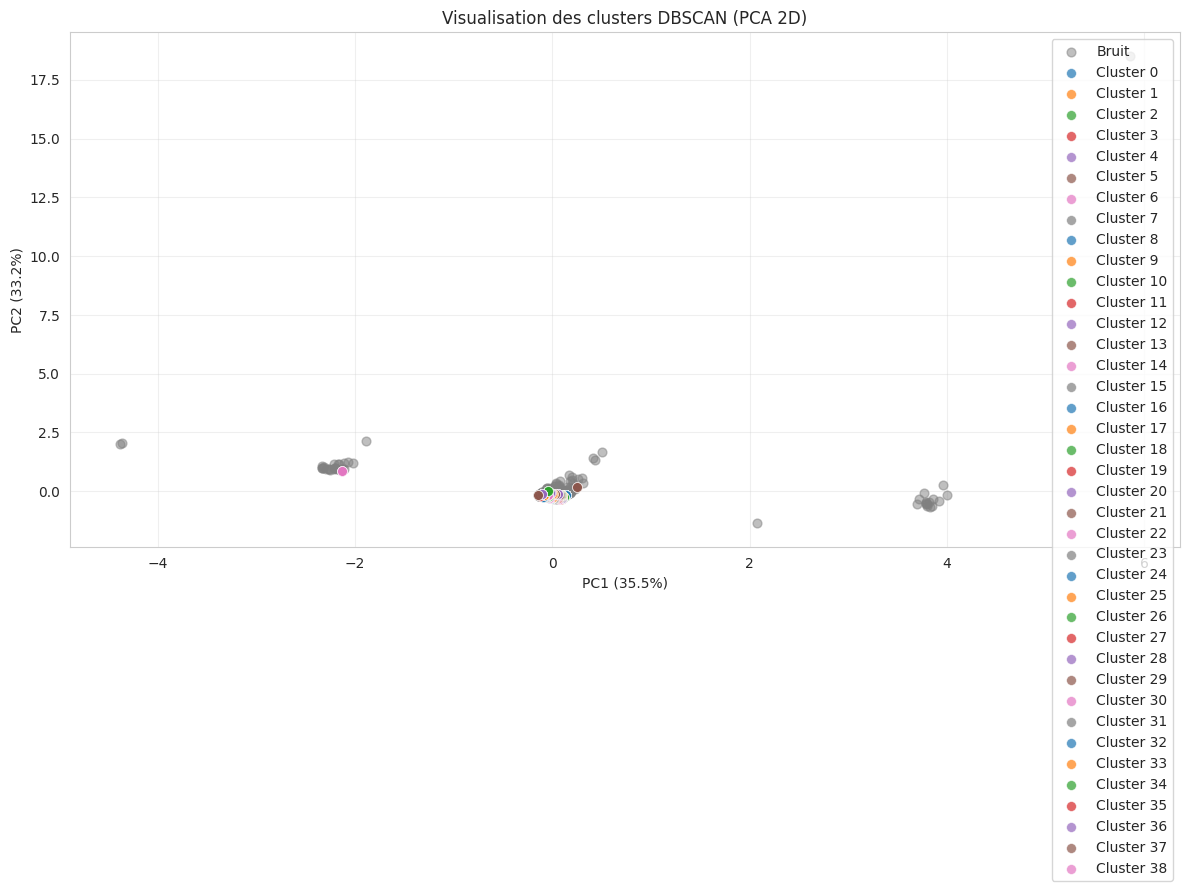

In [12]:
# ============================================
# CELLULE 12 - VISUALISATION PCA 2D (DBSCAN)
# ============================================

print("="*60)
print("VISUALISATION PCA 2D - DBSCAN")
print("="*60)

if n_clusters >= 2:
    # Créer DataFrame pour visualisation
    pca_db_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'cluster': dbscan_labels,
        'frequence': rfm_b2c['frequence'],
        'montant': rfm_b2c['montant']
    })

    plt.figure(figsize=(12, 8))

    # Points bruités en gris
    noise_mask = pca_db_df['cluster'] == -1
    if noise_mask.sum() > 0:
        plt.scatter(pca_db_df.loc[noise_mask, 'PC1'], pca_db_df.loc[noise_mask, 'PC2'],
                    c='gray', label='Bruit', alpha=0.5, s=40)

    # Clusters
    for cluster in sorted(pca_db_df[pca_db_df['cluster'] != -1]['cluster'].unique()):
        mask = pca_db_df['cluster'] == cluster
        plt.scatter(pca_db_df.loc[mask, 'PC1'], pca_db_df.loc[mask, 'PC2'],
                    c=colors[cluster % len(colors)], label=f'Cluster {cluster}',
                    alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('Visualisation des clusters DBSCAN (PCA 2D)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ DBSCAN n'a pas trouvé assez de clusters pour la visualisation")

COMPARAISON K-MEANS vs DBSCAN
 Modèle  Nb clusters  Silhouette  Davies-Bouldin  Points bruités
K-Means            3      0.8657          0.1089               0
 DBSCAN           39      0.8073          0.2585             202


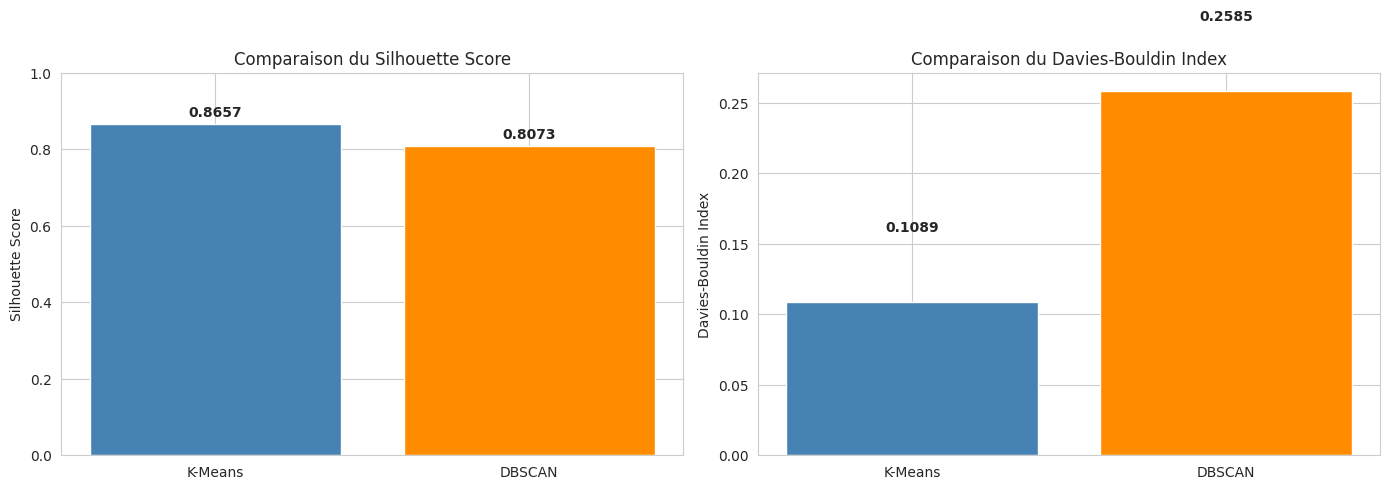


📊 Conclusion :
   ✅ K-Means a de meilleures performances (silhouette plus élevée)


In [13]:
# ============================================
# CELLULE 13 - COMPARAISON DES MODÈLES
# ============================================

print("="*60)
print("COMPARAISON K-MEANS vs DBSCAN")
print("="*60)

# Créer DataFrame de comparaison
comparison_data = []

# K-Means
comparison_data.append({
    'Modèle': 'K-Means',
    'Nb clusters': best_k,
    'Silhouette': silhouette_avg,
    'Davies-Bouldin': davies_bouldin,
    'Points bruités': 0
})

# DBSCAN
if n_clusters >= 2:
    comparison_data.append({
        'Modèle': 'DBSCAN',
        'Nb clusters': n_clusters,
        'Silhouette': silhouette_db if n_clusters >= 2 else None,
        'Davies-Bouldin': davies_db if n_clusters >= 2 else None,
        'Points bruités': n_noise
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4).to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison Silhouette
if len(comparison_df) >= 2:
    axes[0].bar(comparison_df['Modèle'], comparison_df['Silhouette'], color=['steelblue', 'darkorange'])
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('Comparaison du Silhouette Score')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(comparison_df['Silhouette']):
        axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Comparaison Davies-Bouldin
if len(comparison_df) >= 2:
    axes[1].bar(comparison_df['Modèle'], comparison_df['Davies-Bouldin'], color=['steelblue', 'darkorange'])
    axes[1].set_ylabel('Davies-Bouldin Index')
    axes[1].set_title('Comparaison du Davies-Bouldin Index')
    for i, v in enumerate(comparison_df['Davies-Bouldin']):
        axes[1].text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Conclusion :")
if silhouette_avg > (silhouette_db if n_clusters >= 2 else 0):
    print("   ✅ K-Means a de meilleures performances (silhouette plus élevée)")
else:
    print("   ✅ DBSCAN a de meilleures performances (silhouette plus élevée)")

In [14]:
# ============================================
# CELLULE 14 - INTERPRÉTATION MÉTIER
# ============================================

print("="*60)
print("INTERPRÉTATION MÉTIER ET RECOMMANDATIONS")
print("="*60)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION CLUSTERING                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 MODÈLES UTILISÉS :                                                      │
│  ---------------------------------                                           │
│  • K-Means : {} clusters, Silhouette = {:.4f}                              │
│  • DBSCAN : {} clusters, Silhouette = {:.4f}, Bruit = {} clients           │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │
""".format(best_k, silhouette_avg, n_clusters, silhouette_db if n_clusters >= 2 else 0, n_noise))

if silhouette_avg > (silhouette_db if n_clusters >= 2 else 0):
    print("   → K-Means (meilleur silhouette score)")
else:
    print("   → DBSCAN (meilleur silhouette score)")

print("""
│                                                                             │
│  💡 RECOMMANDATIONS MÉTIER :                                                │
│  ---------------------------------                                           │
""")

for cluster in sorted(rfm_b2c['cluster_kmeans'].unique()):
    cluster_data = rfm_b2c[rfm_b2c['cluster_kmeans'] == cluster]
    recence_moy = cluster_data['recence'].mean()
    frequence_moy = cluster_data['frequence'].mean()
    montant_moy = cluster_data['montant'].mean()

    print(f"   📌 Cluster {cluster} : {len(cluster_data)} clients")
    if recence_moy < 30 and frequence_moy > 2 and montant_moy > 200:
        print(f"      → Action : Programme de fidélisation VIP")
    elif recence_moy > 90 and frequence_moy < 2:
        print(f"      → Action : Campagne de réactivation (offre spéciale)")
    elif recence_moy < 60 and frequence_moy < 2:
        print(f"      → Action : Encourager le 2ème achat")
    else:
        print(f"      → Action : Communication standard")

print("""
│                                                                             │
│  📈 ACTIONS CONCRÈTES :                                                     │
│  ---------------------------------                                           │
│  • Clients VIP → offres exclusives, avantages, parrainage                   │
│  • Clients à risque → emailing, promotions, rappels                         │
│  • Nouveaux clients → onboarding, suggestion produits                       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ CLUSTERING TERMINÉ !")

INTERPRÉTATION MÉTIER ET RECOMMANDATIONS

┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION CLUSTERING                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 MODÈLES UTILISÉS :                                                      │
│  ---------------------------------                                           │
│  • K-Means : 3 clusters, Silhouette = 0.8657                              │
│  • DBSCAN : 39 clusters, Silhouette = 0.8073, Bruit = 202 clients           │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │

   → K-Means (meilleur silhouette score)

│                                   